# Model Inputs

"ml_input.csv" can be retrieved from 03-Sample-Prep (single dataframe w/ train and test sets)

### Packages

In [ ]:
import pandas as pd
import numpy as np
import os

import umap

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn import metrics

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import plotly.express as px
import plotly.graph_objects as go

In [4]:
DATA_DIR = "~/Desktop/Projects/media_prediction/"
RANDOM_SEED = 26

### Dataset

In [5]:
# Loading output dataframe from data.ipynb
df = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

# Filter non-specific ec numbers (e.g., 1.1.1,-)
filter = df["ec"].str.contains("-")
df = df[~filter]

# Format for machine learning
df = df[["taxon_id", "media_id", "ec"]].value_counts().reset_index()
df = df.pivot(index=["taxon_id", "media_id"], columns="ec", values="count")
df = df.fillna(0.0).reset_index()

# Filtering into training and test sets (database set vs. MAGs)
bins = df["media_id"].str.contains("unknown")
df_train = df[~bins]
df_test = df[bins]

df.head()

ec,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Split dataset

In [6]:
TARGET = "media_id" # target label

bins1 = df_train["media_id"].str.contains("unknown")
bins2 = df_test["media_id"].str.contains("unknown")
df_train 

# Test case with MAGs
X_train = df_train.drop(["taxon_id", "media_id"], axis=1)
y_train = df_train[TARGET] 
X_test = df_test.drop(["taxon_id", "media_id"], axis=1)
y_test = df_test[TARGET]

# Model

In [16]:
model = umap.UMAP(      
        metric="euclidean",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=40, 
        n_neighbors=62, 
        min_dist=0 
        )

### Fit and transform

In [17]:
X_train_transformed = model.fit_transform(X_train) # fit pipeline and transform training data
X_test_transformed = model.transform(X_test) # transform test data

### Cluster

In [42]:
# Cluster
clusterer = KMeans(n_clusters=80, random_state=RANDOM_SEED)
cluster_labels = clusterer.fit_predict(X_train_transformed)
test_clusters = clusterer.predict(X_test_transformed)

### Metrics

In [ ]:
# UMAP and clustering performance
silhouette_avg = silhouette_score(X_train_transformed, cluster_labels)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

80 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.7348458766937256


# Classifier

In [44]:
y2_train = cluster_labels
y2_test = test_clusters

### Random Forest

In [45]:
rfc = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

rfc.fit(X_train_transformed, y2_train)
print(rfc.predict(X_test_transformed))

[20 72 34  2 34 34 11 34 74 34 34 34 72 11 34  0 34 57 34 53 11 34 53 74
 34 34 34 35 74 72 61 57 48 35 53 34 53 34 34 34 72 34 34 34 11 72 34 74
 11 34 74  0 74 34 34 22  0 48 35 34 11 34 72 57 59 34 11 74 72 74 34 34
 57 57 35 11 11 11 74 11 34 34 34 11 34 74 22 34 57 57 34 34 34 11 74 74
 61 35 53 74 34 65 61 72 34 72 74 34 34 34 34 34 34 34 11 11 74 34 34 34
 34 35 57  0 52 11 34 45 22 11 34 72 53 74 35 34 53 11 34 22 57 74 34  0
 34 48 34 72 57 34 11 53 11 53 34 34 34 34 51 74 72 34 34 34 35 35 11  0
 74 72 57 34 17 72 34 34 34 34 11 11 34 72 22 34 34 74 34 72 59 74 53 52
 57 34  0 72 34  0 34 74 45 53 17 34 35 34 11 11 72 34 34 74  0 34 34 11
 34 61 34 57 53 34 34 34 34 34 72 34 34 72 59  0 11  0 74 11  0 53  0 72
 74 72 72 11 22 22 74]


In [46]:
report = classification_report(
    y_true=y2_test,
    y_pred=rfc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=rfc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("RF ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           2       0.00      0.00      0.00         0
          11       1.00      0.91      0.95        32
          17       1.00      1.00      1.00         2
          19       0.00      0.00      0.00         3
          20       1.00      0.50      0.67         2
          22       1.00      1.00      1.00         7
          34       0.94      1.00      0.97        87
          35       1.00      1.00      1.00        10
          45       1.00      1.00      1.00         2
          48       1.00      1.00      1.00         3
          51       1.00      0.50      0.67         2
          52       0.50      1.00      0.67         1
          53       1.00      1.00      1.00        13
          57       1.00      0.93      0.96        14
          59       1.00      1.00      1.00         3
          61       0.00      0.00      0.00         0
          65       1.00    

### Nearest Neighbors

In [47]:
knc= KNeighborsClassifier(n_neighbors=1)
knc.fit(X_train_transformed, cluster_labels)
distances, indices = knc.kneighbors(X_test_transformed)

print(knc.predict(X_test_transformed))

[20 72 34 57 34 34 11 34 74 34 34 34 72 11 34  0 34 57 34 53 11 34 53 74
 34 34 34 35 74 72 19 57 48 35 53 34 53 34 34 34 72 72 11 34 11 72 34 74
 11 34 74  0 74 34 34 22  0 48 35 34 11 34 72 57 59 34 11 74 72 74 34 34
 57 57 35 11 11 11 74 11 34 34 34 11  0 74 22 34 57 57 34 34 34 11 74 74
 51 35 53 74 34 65 19 72 34 72 74 34 34 34 34 34 34 34 11 11 74 34 34 72
 34 35 57  0 20 11 34 45 22 11 34 72 53 74 35 34 53 11 34 22 57 74 34  0
 34 48 34 72 57 34 11 53 11 53 34 34 34 34 51 74 72 34 34 34 35 35 11  0
 74 72 57 34 17 72 72 34 34 34 11 11 34 72 22 34 34 74 34 72 59 74 53 52
 57 34  0 72 34  0 34 74 45 53 17 34 35 34 11 11 72 34 34 74  0 34 34 11
 34 19 34 57 53 34 34 34 34 34 72 34 34 72 59  0 11  0 74 11  0 53  0 72
 74 72 72 34 22 22 74]


In [48]:
report = classification_report(
    y_true=y2_test,
    y_pred=knc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=knc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("KNN ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
          11       0.97      0.88      0.92        32
          17       1.00      1.00      1.00         2
          19       1.00      1.00      1.00         3
          20       1.00      1.00      1.00         2
          22       1.00      1.00      1.00         7
          34       0.94      0.97      0.95        87
          35       1.00      1.00      1.00        10
          45       1.00      1.00      1.00         2
          48       1.00      1.00      1.00         3
          51       1.00      1.00      1.00         2
          52       1.00      1.00      1.00         1
          53       1.00      1.00      1.00        13
          57       1.00      1.00      1.00        14
          59       1.00      1.00      1.00         3
          65       1.00      1.00      1.00         1
          72       0.92      0.96      0.94        25
          74       1.00    

# Outputs

### Train, clustering labels

In [52]:
# Training data
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
train_df['Set'] = 'Training'
train_df['Target'] = y_train
train_df['KMeans Cluster'] = cluster_labels
train_df['taxon_id'] = df_train["taxon_id"]

# Media cluster labels
media_clusters = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "media-clusters.csv"))
target_label_mapping = dict(zip(media_clusters['media_id'], media_clusters['Media Cluster']))
train_df['Media Cluster'] = train_df['Target'].map(target_label_mapping)

#train_df.to_csv(os.path.join(DATA_DIR, "model", "train-output.csv"), index=False)
train_df.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 36,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,taxon_id,Media Cluster
0,6.830129,1.119115,4.622725,-15.458426,7.159232,8.557269,2.774139,20.419552,-26.083090,-1.711766,...,6.197278,6.354606,3.353917,5.164422,4.234888,Training,J346,71,100.0,6.0
1,9.233161,4.510263,5.049387,2.133639,5.148618,4.597396,4.013432,4.359433,5.881994,5.231225,...,6.244072,4.227017,5.068640,5.443329,4.859480,Training,J386,17,100.0,3.0
2,8.971211,4.012220,4.820234,7.275269,3.950248,4.912436,4.414934,4.946298,4.318140,7.625708,...,5.675347,4.488024,6.825934,5.395233,4.138514,Training,J233,0,100225.0,NaN
3,7.696748,1.051596,2.740061,18.558784,-1.948173,9.830962,2.868693,9.720484,5.822821,15.485526,...,1.097697,7.082317,29.823505,1.984225,1.916600,Training,J22,50,1002526.0,9.0
4,9.317263,4.626888,4.518440,5.006604,4.482603,4.770609,5.255524,2.951485,3.895121,5.402133,...,6.448237,3.192896,4.710999,5.522623,4.170315,Training,1a,59,1004166.0,9.0


### Test, classifier labels

In [53]:
# Test data
test_df = pd.DataFrame(X_test_transformed, columns=[f"Component {i+1}" for i in range(X_test_transformed.shape[1])])
test_df['Set'] = 'Test'
test_df['Target'] = list(df_test['media_id'])
test_df['KMeans Cluster'] = test_clusters
test_df['taxon_id'] = list(df_test['taxon_id'])

# Add classifier labels 
test_df["KNN Classify"] = knc.predict(X_test_transformed)
test_df["RF Classify"] = rfc.predict(X_test_transformed)

#test_df.to_csv(os.path.join(DATA_DIR, "model", "test-output.csv"), index=False)
test_df.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,taxon_id,KNN Classify,RF Classify
0,9.583561,4.340691,5.101655,5.301695,4.700481,5.190484,4.616049,5.358000,5.152044,12.167763,...,5.089057,6.222231,4.587748,4.735178,Test,unknown,20,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,20,20
1,9.248586,4.409340,4.846084,5.785066,4.298287,4.663127,5.230557,2.911167,3.536439,5.800550,...,3.787192,4.688953,5.035044,4.066067,Test,unknown,72,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,72,72
2,9.268225,4.459118,4.912168,5.543317,4.331978,4.724102,5.182258,2.990719,3.806581,5.725456,...,3.460138,4.773334,5.222072,4.132771,Test,unknown,34,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,34,34
3,7.107794,1.479364,3.613019,17.911755,-3.199464,9.691447,1.702086,9.309078,6.691167,15.422735,...,6.041848,30.028799,1.935317,2.529896,Test,unknown,57,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,57,2
4,9.244523,4.441853,4.950911,5.574339,4.322179,4.748961,5.133939,3.194147,3.899703,5.832673,...,3.475830,4.889794,5.259793,4.193675,Test,unknown,34,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,34,34


### ID nearest neighbors

In [54]:
# Add nearest neighbor indices to the test dataframe
knn_df = test_df.copy()
knn_df = knn_df.rename(columns={"KMeans Cluster": "Test Cluster"})
neighbors = pd.DataFrame(indices) # Indices of nearest neighbors from the training set
knn_df['indices'] = neighbors[neighbors.columns[0:]].apply(lambda x: ';'.join(x.dropna().astype(str)), axis=1)
knn_df["indices"] = knn_df["indices"].str.split(';')
knn_df = knn_df.explode("indices")

# Add original indices as a column for the train dataframe
train_index = train_df.copy()
train_index = train_index.rename(columns={"KMeans Cluster": "Train Cluster"})
train_index["indices"] = df_train.index
train_index["indices"] = train_index["indices"].astype(str)

# Merge to label nearest neighbors
left = knn_df.copy()
right = train_index[["indices", "Target", "taxon_id", "Media Cluster"]]
right = right.rename(columns={"Target": "neighbor_media_id", "taxon_id": "neighbor_taxon_id", "Cluster": "neighbor_cluster"})
merged = pd.merge(left, right, on="indices", how="left")

#merged.to_csv(os.path.join(DATA_DIR, "model", "ml-model-output.csv"), index=False)
merged.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Set,Target,Test Cluster,taxon_id,KNN Classify,RF Classify,indices,neighbor_media_id,neighbor_taxon_id,Media Cluster
0,9.583561,4.340691,5.101655,5.301695,4.700481,5.190484,4.616049,5.358000,5.152044,12.167763,...,Test,unknown,20,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,20,20,1022,J22,137993.0,9.0
1,9.248586,4.409340,4.846084,5.785066,4.298287,4.663127,5.230557,2.911167,3.536439,5.800550,...,Test,unknown,72,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,72,72,4438,J14,28129.0,19.0
2,9.268225,4.459118,4.912168,5.543317,4.331978,4.724102,5.182258,2.990719,3.806581,5.725456,...,Test,unknown,34,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,34,34,1189,J284,1434374.0,7.0
3,7.107794,1.479364,3.613019,17.911755,-3.199464,9.691447,1.702086,9.309078,6.691167,15.422735,...,Test,unknown,57,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,57,2,7062,J58,58121.0,18.0
4,9.244523,4.441853,4.950911,5.574339,4.322179,4.748961,5.133939,3.194147,3.899703,5.832673,...,Test,unknown,34,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,34,34,1383,J1258,1485545.0,7.0


### Feature importance

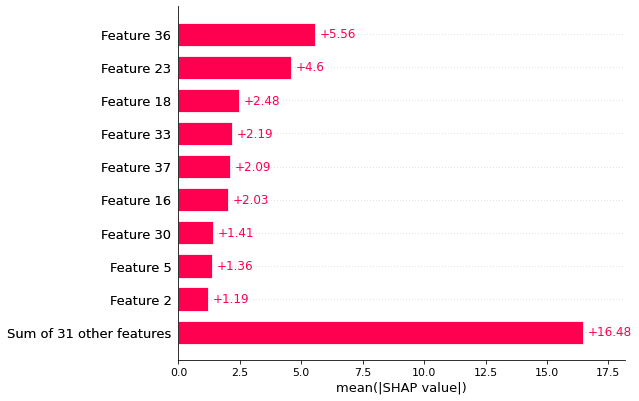

In [55]:
import xgboost
import shap

XG_train = X_train_transformed
yG_train = cluster_labels
XG_test = X_test_transformed
yG_test = test_clusters

model = xgboost.XGBRegressor().fit(XG_train, yG_train)

explainer = shap.Explainer(model)
shap_values = explainer(XG_train) #XG_test

shap.plots.initjs()

#shap.plots.beeswarm(shap_values) #, max_display=40
#shap.plots.waterfall(shap_values[0])
#shap.plots.force(shap_values[:500])
#shap.plots.bar(shap_values.abs.max(0))

shap.plots.bar(shap_values)

# Visualization

### n dimensions

In [57]:
# Highest-importance features (set var to easily change vis)
dim1 = "Component 36" # 31 38
dim2 = "Component 23" # 13 33

# Plot the training points
fig = px.scatter(
    data_frame = train_df,
    x = dim1,
    y = dim2, 
    color = "Media Cluster",
    hover_data = ["taxon_id", "Target", "KMeans Cluster"],
    opacity = 0.3
) 

# Add the test points as a scatter trace
fig.add_trace(
    go.Scatter(
        x=test_df[dim1],  # x coordinates
        y=test_df[dim2],  # y coordinates
        mode='markers',
        marker=dict(
            color='black',  
            size=5,  
            opacity=1.0 
        ),
        text=test_df["taxon_id"]  # marker hover text
    )
)

# Opacity slider
steps = []
for i in range(11):  # 0 to 1 in steps of 0.1
    step = dict(
        method="restyle",
        args=[{"marker.opacity": [i/20]}, [0]],  # Adjust opacity of the first trace only
        label=str(i/20)
    )
    steps.append(step)
sliders = [dict(
    active=3,  # initial value corresponding to opacity=0.3
    currentvalue={"prefix": "Opacity: "},
    pad={"t": 50},
    steps=steps
)]

# Make pretty
fig.update_coloraxes(showscale=False)
fig.update_layout(
    sliders=sliders,
    title="Fenix21 (Global Structure)", # Local => limit axis ranges
    template="plotly_white",
    showlegend=False,
    width=500, 
    height=500 
)

#fig.update_yaxes(range=[2.25, 4.25])
#fig.update_xaxes(range=[2, 8])

fig.show()

In [59]:
# For thesis:

fig = px.scatter(
    data_frame = train_df,
    x = dim1,
    y = dim2, 
    color = "KMeans Cluster",
    hover_data = ["taxon_id", "Target", "Media Cluster"],
    opacity = 0 #0.3 #Toggle training points
) 

fig.add_trace(
    go.Scatter(
        x=test_df[dim1], 
        y=test_df[dim2], 
        mode='markers',
        marker=dict(color='black', size=5, opacity=1.0)
    )
)

fig.update_coloraxes(showscale=False)
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    width=500, 
    height=500
)

# Toggle for global/local structure
#fig.update_yaxes(range=[2.25, 4.25])
#fig.update_xaxes(range=[2, 8])

fig.show()

# Prediction

## Prediction dataframes / statistics

In [60]:
predictor = merged.copy()
predictor = predictor.drop(predictor.iloc[:,0:42], axis=1)
predictor = predictor.drop('indices', axis=1)

#predictor.to_csv("~/Desktop/media_mapping/prediction_test_v3/TEST20.csv", index=False) # save under different names for further analysis with each seed
predictor.head()

,Test Cluster,taxon_id,KNN Classify,RF Classify,neighbor_media_id,neighbor_taxon_id,Media Cluster
0,20,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,20,20,J22,137993.0,9.0
1,72,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,72,72,J14,28129.0,19.0
2,34,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,34,34,J284,1434374.0,7.0
3,57,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,57,2,J58,58121.0,18.0
4,34,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,34,34,J1258,1485545.0,7.0


In [61]:
df = predictor[["taxon_id", "Test Cluster", "KNN Classify", "RF Classify", "neighbor_taxon_id", "neighbor_media_id", "Media Cluster"]]
df = df.rename(columns={
    "Test Cluster": "KM",
    "KNN Classify": "KN", 
    "RF Classify": "RF",
    "neighbor_media_id": "KN Neighbor Media",
    "neighbor_taxon_id": "KN Neighbor ID"
})
df.head()

,taxon_id,KM,KN,RF,KN Neighbor ID,KN Neighbor Media,Media Cluster
0,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,20,20,20,137993.0,J22,9.0
1,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,72,72,72,28129.0,J14,19.0
2,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,34,34,34,1434374.0,J284,7.0
3,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,57,57,2,58121.0,J58,18.0
4,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,34,34,34,1485545.0,J1258,7.0


## Single-neighbor test case

In [71]:
# Search for media with trace element solutions

media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #mediadive-complete.csv source?

trace_element = media_df["sub_solutions"].str.contains("trace")
trace_media = media_df[trace_element]
te_list = trace_media["media_id"].to_list()

print(len(trace_media))
trace_media.head()

52


,media_id,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml
85,88,"[154, 155]","['Main sol. 88', ""Allen's trace element soluti...","['(NH4)2SO4', 'KH2PO4', 'MgSO4 x 7 H2O', 'CaCl...","[27, 11, 8, 7, 82, 16, 4, 36, 196, 35, 39, 9, ...","[1.28713, 0.277228, 0.247525, 0.0693069, 0.019...",[[{'step': 'Dissolve ingredients (except yeast...,"[""Allen's trace element solution""]",[155],[10]
86,88a,"[156, 155]","['Main sol. 88a', ""Allen's trace element solut...","['(NH4)2SO4', 'KH2PO4', 'MgSO4 x 7 H2O', 'CaCl...","[27, 11, 8, 7, 82, 80, 16, 54, 4, 36, 196, 35,...","[1.3, 0.28, 0.25, 0.07, 0.02, 10, 0.5, 0.5, No...",[[{'step': 'Dissolve ingredients (except sulfu...,"[""Allen's trace element solution""]",[155],[10]
87,88b,"[5562, 155]","['Main sol. 88b', ""Allen's trace element solut...","['(NH4)2SO4', 'KH2PO4', 'MgSO4 x 7 H2O', 'CaCl...","[27, 11, 8, 7, 82, 4, 80, 16, 199, 25, 54, 36,...","[1.3, 0.28, 0.25, 0.07, 0.02, None, 1, 0.2, 2,...","[[{'step': 'Prepare medium , then add (per lit...","[""Allen's trace element solution""]",[155],[10]
88,88c,"[158, 155]","['Main sol. 88c', ""Allen's trace element solut...","['(NH4)2SO4', 'KH2PO4', 'MgSO4 x 7 H2O', 'CaCl...","[27, 11, 8, 7, 82, 65, 16, 164, 101, 54, 4, 36...","[1.3, 0.28, 0.25, 0.07, 0.02, 2, 1, 1, 0.5, 0....",[[{'step': 'Dissolve ingredients (except thios...,"[""Allen's trace element solution""]",[155],[10]
184,182,"[308, 155]","['Main sol. 182', ""Allen's trace element solut...","['Yeast extract', 'Casamino acids', 'KH2PO4', ...","[16, 101, 11, 27, 8, 7, 4, 36, 196, 35, 39, 9,...","[1, 1, 3.1, 2.5, 0.2, 0.25, None, 0.18, 0.45, ...",[[{'step': 'Dissolve all compounds except yeas...,"[""Allen's trace element solution""]",[155],[10]


In [73]:
# Find prediction results for those media

df = pd.read_csv(os.path.join(DATA_DIR, "data", "TEST1.csv"))

df = df.rename(columns={"neighbor_media_id": "media_id"})
filter = df["media_id"].isin(te_list)
df = df[filter]

print(len(df))

prediction = pd.merge(left=df, right=trace_media, on="media_id", how="left")

print(len(prediction))
prediction.head()

0
0


,Test Cluster,taxon_id,KNN Classify,RF Classify,media_id,neighbor_taxon_id,Media Cluster,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml


Note: it appears none of the suggested neighboring media currently have trace element solutions included as sub-solutions, regardless, let's take our main outlier as a test case:

In [75]:
df = pd.read_csv(os.path.join(DATA_DIR, "data", "TEST1.csv"))
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"

df = df.rename(columns={"neighbor_media_id": "media_id"})
boi = df["taxon_id"].str.contains("Bin.003.fastaCG_F")
data = df[boi]

prediction = pd.merge(left=data, right=media_df, on="media_id", how="left")

print(len(prediction))
prediction.head()

1


,Test Cluster,taxon_id,KNN Classify,RF Classify,media_id,neighbor_taxon_id,Media Cluster,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml
0,67,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,67,67,J363,2499157.0,NaN,[4084],['Main sol. J363'],"['Salt Solution I', 'Salt Solution II', 'Trypt...","[1143, 1144, 124, 16, 5, 214, 171, 199, 1852, ...","[None, None, 9.96016, 4.98008, 0.249004, 0.249...",[[{'step': 'Adjust pH to 6.7. Prepare medium a...,[],[],[]


Let's map some cofactor concentrations:

In [79]:
# Load ec and cofactor info

trco = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
trco = trco[["Query EC", "CofactorExtracted", "Fe-S cluster", "CofactorFinal"]]
trco = trco.rename(columns={"Query EC": "ec"})

trta = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

cfdf = pd.merge(left=trta, right=trco, on="ec", how="left")

cfdf.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
0,1a,Comamonas testosteroni,1886637.0,uniprot,2.6.1.1,NaN,NaN,NaN
1,1a,Comamonas testosteroni,1886637.0,uniprot,4.1.1.12,NaN,NaN,NaN
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
4,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.13.23,NaN,NaN,NaN


In [80]:
# Focus on metals / trace elements:
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv")) #TODO: metals list as a given
meli = metals["Metals"].to_list()
filter = cfdf["CofactorFinal"].isin(meli)
meco = cfdf[filter]

meco.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
7,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,Ca(2+),False,Ca
8,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,heme c,False,Fe
15,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.12.15,Fe cation,False,Fe


Now: need a list of each trace element solution utilizing these ~90+ cofactors, and then 1) map the distributions of these concentrations (linear regression, just plot means, distributions, etc.), align these values with the "CofactorFinal", and attempt for a given test case to be able to suggest concentrations based on the EC numbers present (similar to Method 1, but needs refinement)

In [81]:
comp = meco[["media_id", "taxon_id", "source", "ec", "CofactorFinal"]]
comp = comp.dropna()

# Filters
bins = comp["source"].str.contains("KBase") # Separate MAGs from training database
boi = comp["taxon_id"].str.contains("Bin.003.fastaCG_F") # Isolate a single test MAG

co = comp[~bins]
ct = comp[bins]
test = comp[boi]

#Create, merge, format counts 
coct = co["CofactorFinal"].value_counts().reset_index()
sum1 = coct["count"].sum(axis=0)
coct['ratio1'] = coct['count'].div(sum1)
coct = coct.rename(columns={"count": "count1"})

ctct = ct["CofactorFinal"].value_counts().reset_index()
sum2 = ctct["count"].sum(axis=0)
ctct['ratio2'] = ctct['count'].div(sum2)
ctct = ctct.rename(columns={"count": "count2"})

tect = test["CofactorFinal"].value_counts().reset_index()
sum3 = tect["count"].sum(axis=0)
tect['ratio3'] = tect['count'].div(sum3)
tect = tect.rename(columns={"count": "count3"})

cf_df = pd.merge(left=coct, right=ctct, on="CofactorFinal", how="left")
cf_df = pd.merge(left=cf_df, right=tect, on="CofactorFinal", how="left")
cf_df = cf_df.fillna(0)

x = cf_df["count1"].sum(axis=0)
y = cf_df["count2"].sum(axis=0)
z = cf_df["count3"].sum(axis=0)
print(x, "annotated bin cofactors", y, "annotated database cofactors")


# Relabel cofactors to group organic
relabeled_cofactors = cf_df.copy()
dictionary = {
    "a monovalent": "UM",
    "metal": "UM"
}

for key in dictionary.keys():
    relabeled_cofactors["CofactorFinal"] = relabeled_cofactors["CofactorFinal"].str.replace(key, dictionary[key])

relabeled_cofactors = relabeled_cofactors.groupby(['CofactorFinal'])[['count1', 'ratio1', 'count2', 'ratio2', 'count3', 'ratio3']].sum().reset_index()
relabeled_cofactors = relabeled_cofactors.sort_values(['count1'], ascending=[False])


# Format for visualization
df1 = relabeled_cofactors[["CofactorFinal", "count1", "ratio1"]]
df2 = relabeled_cofactors[["CofactorFinal", "count2", "ratio2"]]
df3 = relabeled_cofactors[["CofactorFinal", "count3", "ratio3"]]

df1 = df1.rename(columns={"count1": "ct", "ratio1": "ra"})
df2 = df2.rename(columns={"count2": "ct", "ratio2": "ra"})
df3 = df3.rename(columns={"count3": "ct", "ratio3": "ra"})

df1["Set"] = "Training"
df2["Set"] = "Test"
df3["Set"] = "Bin 003 CG_F"

frames = df1, df2, df3
df = pd.concat(frames)
df.head()

1652619 annotated bin cofactors 94312.0 annotated database cofactors


,CofactorFinal,ct,ra,Set
6,Mg,419329.0,0.253736,Training
15,Zn,292936.0,0.177256,Training
3,Fe,234396.0,0.141833,Training
7,Mn,173112.0,0.104750,Training
0,Ca,128564.0,0.077794,Training


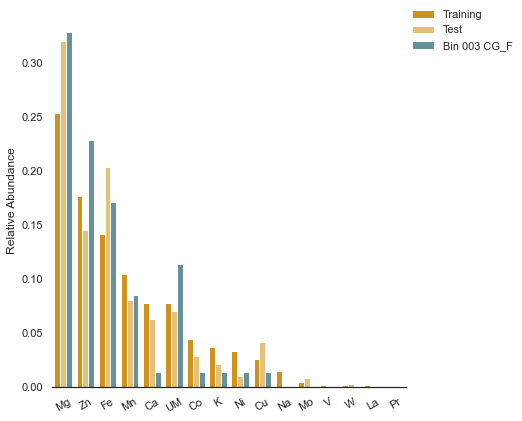

In [82]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#ee9b00", "#f5c767", "#5c96a5"]

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=df, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Abundance")
g.tick_params(axis='x', rotation=30)
g.legend.set_loc("upper right")
g.legend.set_title("")